# Notebook 03: Act I - Spatial Failures & Radial Residuals

**Purpose:** Demonstrate where established models break down as a function of normalized galactic radius.

- **Cusp-Core Test:** Stack NFW residuals $(V_{\rm obs} - V_{\rm NFW})$ vs $R/R_d$ to expose systematic positive bias in the inner disk - the signature of the cusp-core problem.
- **Stacked Radial Residuals:** Side-by-side comparison of all four models confirms the Rational Taper resolves the inner-disk problem while remaining unbiased in the outer disk.

Model velocities are reconstructed using `src.physics.compute_total_model_velocity()` - no physics logic in this notebook.

**Prerequisites:** Run `notebooks/00_setup.ipynb` first.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.database import get_session, init_db, query_fits_as_dataframe
from src.physics import compute_total_model_velocity
from src.utils import get_project_root, setup_logger

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

logger = setup_logger('notebook_03')
project_root = get_project_root()
engine = init_db()
session = get_session(engine)

FIGURES_DIR = project_root / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

2026-03-13 15:45:05 | INFO     | src.database | Database initialized at C:\Projects\ISM\tapered-model-comparison\data\processed\galaxy_dynamics.db


Setup complete.


## 1. Data Assembly

We bulk-load all radial profiles in a single query (avoids N+1 DB calls).  
Model velocities are reconstructed from the stored `param1`/`param2` columns.

In [2]:
# Bulk load all profiles
all_profiles = pd.read_sql('SELECT * FROM radial_profiles ORDER BY galaxy_id, radius_kpc', engine)
print(f'Loaded {len(all_profiles)} radial profile rows across {all_profiles["galaxy_id"].nunique()} galaxies.')

# Galaxy metadata: need r_disk_kpc to normalise radius
gal_meta = pd.read_sql('SELECT galaxy_id, r_disk_kpc FROM galaxies', engine).set_index('galaxy_id')

# All fit results
fits_df = query_fits_as_dataframe(session)
print(f'Loaded {len(fits_df)} fit rows.')

Loaded 3391 radial profile rows across 175 galaxies.
Loaded 700 fit rows.


In [3]:
ALL_MODELS = ['nfw', 'mond_fixed', 'mond_free', 'rational_taper']

# Build per-model residual dataframes
model_rows = {m: [] for m in ALL_MODELS}

for gid, prof_group in all_profiles.groupby('galaxy_id'):
    prof = prof_group.sort_values('radius_kpc')

    # Disk scale length for radius normalisation
    if gid not in gal_meta.index:
        continue
    r_disk = gal_meta.loc[gid, 'r_disk_kpc']
    if not (np.isfinite(r_disk) and r_disk > 0):
        continue

    radius  = prof['radius_kpc'].values.astype(float)
    v_obs   = prof['v_obs'].values.astype(float)
    v_bary  = prof['v_baryon_total'].values.astype(float)
    r_norm  = radius / r_disk

    # Skip if v_baryon_total has NaNs (shouldn't happen after setup)
    if np.any(~np.isfinite(v_bary)):
        continue

    gal_fits = fits_df[fits_df['galaxy_id'] == gid]

    for model_name in ALL_MODELS:
        row = gal_fits[gal_fits['model_name'] == model_name]
        if row.empty:
            continue
        fit = row.iloc[0]
        if not fit['converged']:
            continue

        p1 = fit['param1']
        p2 = fit['param2']
        if not np.isfinite(float(p1 if p1 is not None else float('nan'))):
            continue

        try:
            v_model = compute_total_model_velocity(
                radius, v_bary, model_name,
                param1=float(p1),
                param2=float(p2) if p2 is not None else None,
            )
        except Exception as exc:
            logger.warning('Skipping %s [%s]: %s', gid, model_name, exc)
            continue

        residuals = v_obs - v_model
        for rn, res in zip(r_norm, residuals):
            model_rows[model_name].append({'r_norm': rn, 'residual': res})

model_dfs = {m: pd.DataFrame(model_rows[m]) for m in ALL_MODELS}
for m, df in model_dfs.items():
    print(f'{m:20s}: {len(df)} data points')

nfw                 : 3391 data points
mond_fixed          : 3391 data points
mond_free           : 3391 data points
rational_taper      : 3391 data points


## 2. Cusp-Core Test: Stacked NFW Residuals

A systematic positive bias at $R/R_d < 1$ indicates that NFW over-predicts the central velocity - the velocity-space signature of the cusp-core problem.

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\03_cusp_core_nfw_residuals.png


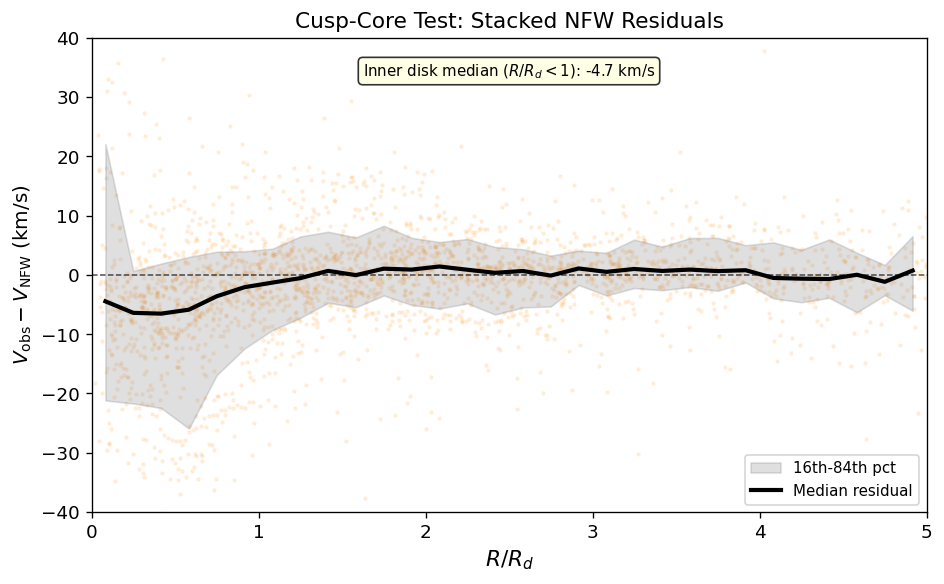

In [4]:
def bin_residuals(df, r_max=5.0, n_bins=30):
    """Bin residuals in R/R_d and compute running statistics."""
    bins = np.linspace(0, r_max, n_bins + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    df = df.copy()
    df['r_bin'] = pd.cut(df['r_norm'], bins=bins, labels=False, include_lowest=True)
    stats = df.groupby('r_bin')['residual'].agg(
        median='median',
        q16=lambda x: x.quantile(0.16),
        q84=lambda x: x.quantile(0.84),
        n='count',
    ).reset_index()
    stats['r_center'] = centers[stats['r_bin'].astype(int).values]
    return stats[stats['n'] >= 3]  # require at least 3 points per bin

nfw_stats = bin_residuals(model_dfs['nfw'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(model_dfs['nfw']['r_norm'], model_dfs['nfw']['residual'],
           alpha=0.1, s=3, color='darkorange', rasterized=True)
ax.fill_between(nfw_stats['r_center'], nfw_stats['q16'], nfw_stats['q84'],
                alpha=0.25, color='gray', label='16th-84th pct')
ax.plot(nfw_stats['r_center'], nfw_stats['median'], 'k-', lw=2.5, label='Median residual')
ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.7)
ax.set_xlabel(r'$R / R_d$', fontsize=13)
ax.set_ylabel(r'$V_{\rm obs} - V_{\rm NFW}$ (km/s)', fontsize=12)
ax.set_title('Cusp-Core Test: Stacked NFW Residuals', fontsize=13)
ax.set_xlim(0, 5)
ax.set_ylim(-40, 40)
ax.legend(fontsize=9)

# Annotate inner-disk median
inner_mask = model_dfs['nfw']['r_norm'] < 1.0
inner_med = model_dfs['nfw'].loc[inner_mask, 'residual'].median()
ax.text(0.5, 0.92, f'Inner disk median ($R/R_d < 1$): {inner_med:+.1f} km/s',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

plt.tight_layout()
out_path = FIGURES_DIR / '03_cusp_core_nfw_residuals.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

In [5]:
# === Text log: cusp-core NFW residuals ===
inner_nfw = model_dfs['nfw'][model_dfs['nfw']['r_norm'] < 1.0]['residual']
outer_nfw = model_dfs['nfw'][model_dfs['nfw']['r_norm'] > 3.0]['residual']

print('=== Cusp-Core Test: NFW Residuals ===')
print(f'Inner disk (R/Rd < 1):')
print(f'  Median residual:   {inner_nfw.median():+.2f} km/s')
print(f'  16th-84th pct:     [{inner_nfw.quantile(0.16):+.2f}, {inner_nfw.quantile(0.84):+.2f}] km/s')
print(f'  N points:          {len(inner_nfw)}')
print(f'Outer disk (R/Rd > 3):')
print(f'  Median residual:   {outer_nfw.median():+.2f} km/s')
print(f'  16th-84th pct:     [{outer_nfw.quantile(0.16):+.2f}, {outer_nfw.quantile(0.84):+.2f}] km/s')
print(f'  N points:          {len(outer_nfw)}')
print()
neg_inner = (inner_nfw < 0).mean() * 100
print(f'Fraction of inner-disk points with negative residual: {neg_inner:.1f}%')
print('(Negative = NFW over-predicts observed velocity = cusp-core signature)')


=== Cusp-Core Test: NFW Residuals ===
Inner disk (R/Rd < 1):
  Median residual:   -4.73 km/s
  16th-84th pct:     [-20.62, +3.73] km/s
  N points:          806
Outer disk (R/Rd > 3):
  Median residual:   +0.23 km/s
  16th-84th pct:     [-3.81, +4.84] km/s
  N points:          1373

Fraction of inner-disk points with negative residual: 73.3%
(Negative = NFW over-predicts observed velocity = cusp-core signature)


## 3. Side-by-Side Stacked Residuals - All Four Models

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\03_stacked_residuals_all_models.png


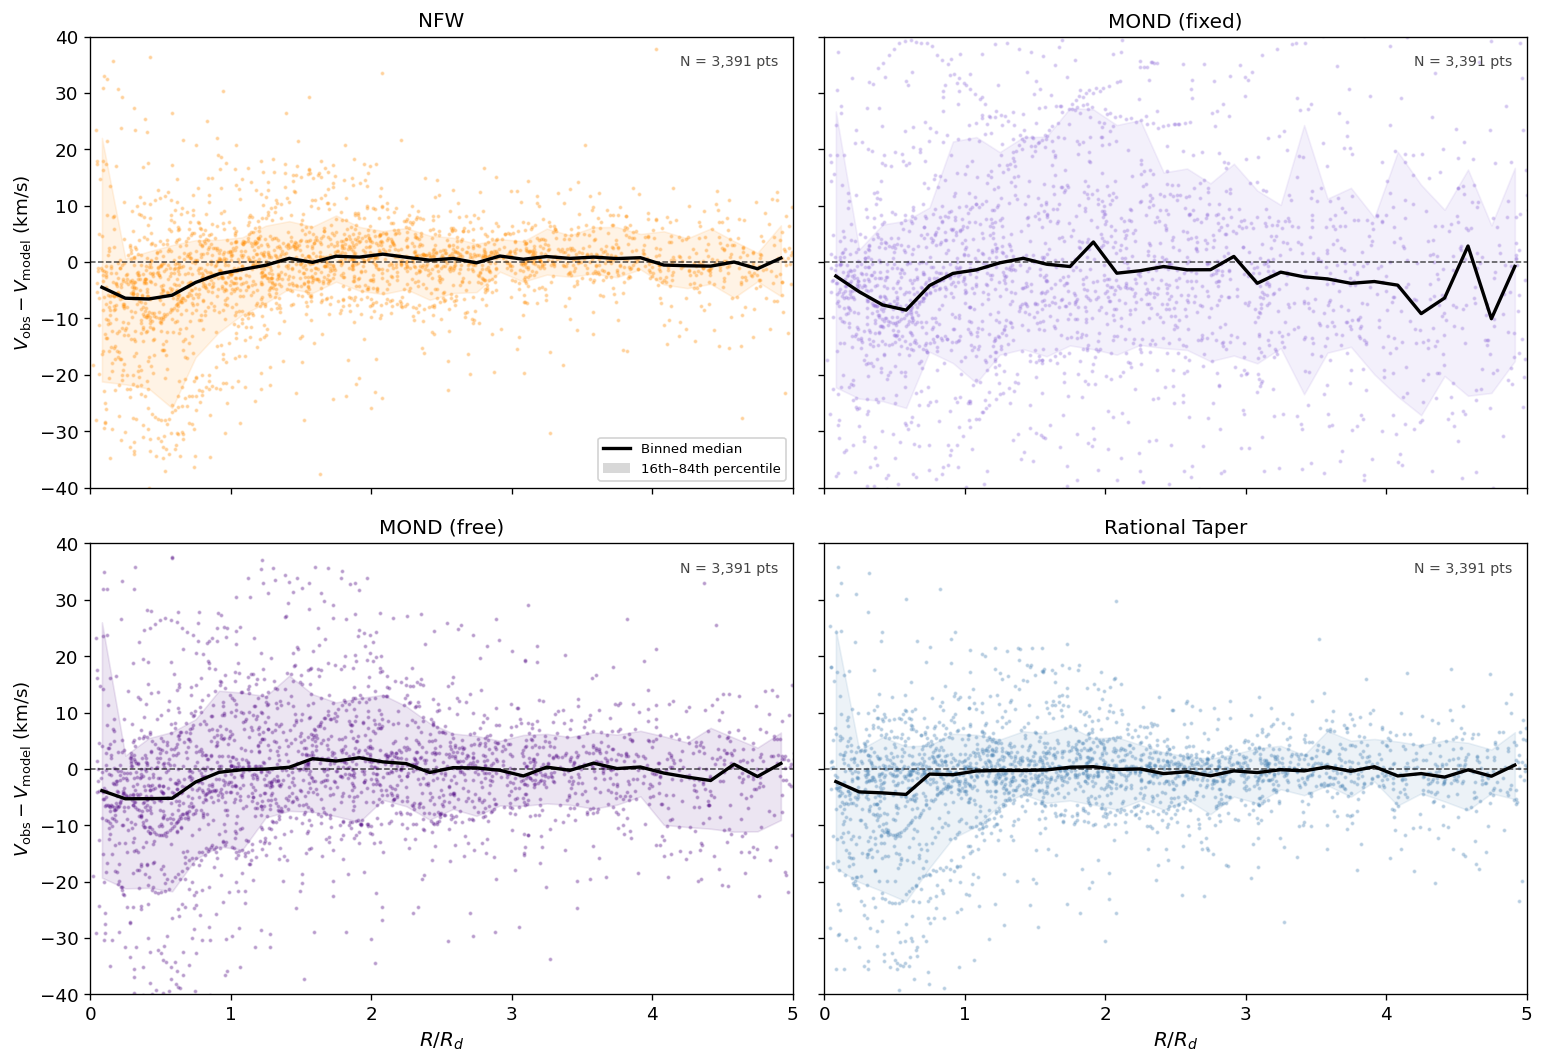

In [6]:
_model_config = {
    'nfw':            ('NFW',             'darkorange'),
    'mond_fixed':     ('MOND (fixed)',     'mediumpurple'),
    'mond_free':      ('MOND (free)',      'indigo'),
    'rational_taper': ('Rational Taper',   'steelblue'),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
panel_order = ['nfw', 'mond_fixed', 'mond_free', 'rational_taper']

for ax, model_name in zip(axes.flatten(), panel_order):
    df = model_dfs[model_name]
    label, color = _model_config[model_name]

    if df.empty:
        ax.text(0.5, 0.5, label + '\n(no data)', ha='center', va='center', transform=ax.transAxes)
        continue

    stats = bin_residuals(df)

    ax.scatter(df['r_norm'], df['residual'], alpha=0.25, s=2, color=color, rasterized=True)
    ax.fill_between(stats['r_center'], stats['q16'], stats['q84'],
                    alpha=0.1, color=color)
    ax.plot(stats['r_center'], stats['median'], 'k-', lw=2.0)
    ax.axhline(0, color='k', lw=0.9, ls='--', alpha=0.7)
    ax.set_title(label, fontsize=12)
    ax.set_xlim(0, 5)
    ax.set_ylim(-40, 40)
    # N data points annotation
    n_pts = len(df)
    ax.text(0.98, 0.96, f'N = {n_pts:,} pts', transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color='#444')
    # Band legend on first panel only
    if model_name == 'nfw':
        from matplotlib.patches import Patch
        ax.legend(
            handles=[
                plt.Line2D([0], [0], color='k', lw=2, label='Binned median'),
                Patch(facecolor='gray', alpha=0.3, label='16th–84th percentile'),
            ],
            fontsize=8, loc='lower right', framealpha=0.85
        )

for ax in axes[1]:
    ax.set_xlabel(r'$R / R_d$', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel(r'$V_{\rm obs} - V_{\rm model}$ (km/s)', fontsize=11)

plt.tight_layout()
out_path = FIGURES_DIR / '03_stacked_residuals_all_models.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

In [7]:

# === Text log: stacked residuals - all four models ===
zones = {
    'Inner (R/Rd < 1)':      lambda df: df['r_norm'] < 1.0,
    'Mid (1 â‰¤ R/Rd â‰¤ 3)':   lambda df: (df['r_norm'] >= 1.0) & (df['r_norm'] <= 3.0),
    'Outer (R/Rd > 3)':      lambda df: df['r_norm'] > 3.0,
}
model_labels = {
    'nfw':            'NFW',
    'mond_fixed':     'MOND (fixed)',
    'mond_free':      'MOND (free)',
    'rational_taper': 'Rational Taper',
}

print('=== Stacked Radial Residuals: Median (V_obs - V_model) by Zone ===')
header = f'{"Zone":<26}' + ''.join(f'{lbl:>18}' for lbl in model_labels.values())
print(header)
print('-' * (26 + 18 * 4))

for zone_name, mask_fn in zones.items():
    row = f'{zone_name:<26}'
    for mname in model_labels:
        df = model_dfs[mname]
        sub = df.loc[mask_fn(df), 'residual']
        med = sub.median() if len(sub) > 0 else float('nan')
        row += f'{med:>+17.2f} '
    print(row)

print()
print('Units: km/s.  Positive = model under-predicts (obs > model).')
print('               Negative = model over-predicts (obs < model).')


=== Stacked Radial Residuals: Median (V_obs - V_model) by Zone ===
Zone                                     NFW      MOND (fixed)       MOND (free)    Rational Taper
--------------------------------------------------------------------------------------------------
Inner (R/Rd < 1)                      -4.73             -4.98             -4.04             -2.49 
Mid (1 â‰¤ R/Rd â‰¤ 3)                +0.48             -0.43             +0.56             -0.27 
Outer (R/Rd > 3)                      +0.23             -2.37             -0.15             +0.12 

Units: km/s.  Positive = model under-predicts (obs > model).
               Negative = model over-predicts (obs < model).


In [8]:
# === Summary: key values for reference ===
def zone_median(model_name, mask_fn):
    df = model_dfs[model_name]
    sub = df.loc[mask_fn(df), 'residual']
    return sub.median() if len(sub) > 0 else float('nan')

inner = lambda df: df['r_norm'] < 1.0
mid   = lambda df: (df['r_norm'] >= 1.0) & (df['r_norm'] <= 3.0)
outer = lambda df: df['r_norm'] > 3.0

nfw_inner = zone_median('nfw', inner)
rt_inner  = zone_median('rational_taper', inner)
nfw_outer = zone_median('nfw', outer)
rt_outer  = zone_median('rational_taper', outer)
rt_mid    = zone_median('rational_taper', mid)

n_inner_nfw = int((model_dfs['nfw']['r_norm'] < 1.0).sum())
n_outer_nfw = int((model_dfs['nfw']['r_norm'] > 3.0).sum())

print('=== Notebook 03 Summary: Spatial Residuals ===')
print(f'NFW  inner-disk median (R/Rd < 1):  {nfw_inner:+.2f} km/s  (N={n_inner_nfw})')
print(f'RT   inner-disk median (R/Rd < 1):  {rt_inner:+.2f} km/s')
print(f'RT   mid-disk  median (1<R/Rd<3):   {rt_mid:+.2f} km/s')
print(f'NFW  outer-disk median (R/Rd > 3):  {nfw_outer:+.2f} km/s  (N={n_outer_nfw})')
print(f'RT   outer-disk median (R/Rd > 3):  {rt_outer:+.2f} km/s')
print()

# --- Dynamic interpretation ---
ZERO_THRESH = 1.0  # km/s - below this, median is "consistent with zero"
IMPROVEMENT_FACTOR = 1.5  # RT inner must be this much smaller than NFW to call it "substantially reduced"

inner_improvement = abs(nfw_inner) / abs(rt_inner) if rt_inner != 0 else float('inf')
rt_inner_near_zero = abs(rt_inner) < ZERO_THRESH
rt_mid_near_zero   = abs(rt_mid)   < ZERO_THRESH
rt_outer_near_zero = abs(rt_outer) < ZERO_THRESH

# Inner-disk assessment
if rt_inner_near_zero:
    inner_desc = f'The RT inner-disk residual ({rt_inner:+.2f} km/s) is consistent with zero.'
elif inner_improvement >= IMPROVEMENT_FACTOR:
    direction = 'over-predicts' if rt_inner < 0 else 'under-predicts'
    inner_desc = (f'The RT inner-disk residual ({rt_inner:+.2f} km/s) is substantially smaller '
                  f'than NFW ({nfw_inner:+.2f} km/s), though RT still slightly {direction} '
                  f'inner velocities (by {abs(rt_inner):.1f} km/s median).')
else:
    inner_desc = (f'The RT inner-disk median ({rt_inner:+.2f} km/s) is not a dramatic improvement '
                  f'over NFW ({nfw_inner:+.2f} km/s) in the inner disk.')

# Mid and outer assessment
zones_near_zero = [z for z, near in [('mid', rt_mid_near_zero), ('outer', rt_outer_near_zero)] if near]
zones_biased    = [z for z, near in [('mid', rt_mid_near_zero), ('outer', rt_outer_near_zero)] if not near]

if zones_near_zero and not zones_biased:
    outer_desc = (f'The mid- and outer-disk RT residuals ({rt_mid:+.2f}, {rt_outer:+.2f} km/s) '
                  f'are consistent with zero - no systematic outer-disk bias.')
elif zones_biased:
    outer_desc = (f'The RT mid-disk ({rt_mid:+.2f} km/s) and outer-disk ({rt_outer:+.2f} km/s) '
                  f'residuals show a residual bias in the {", ".join(zones_biased)} zone(s).')
else:
    outer_desc = (f'RT outer residuals: mid={rt_mid:+.2f} km/s, outer={rt_outer:+.2f} km/s.')

print(inner_desc)
print(outer_desc)


=== Notebook 03 Summary: Spatial Residuals ===
NFW  inner-disk median (R/Rd < 1):  -4.73 km/s  (N=806)
RT   inner-disk median (R/Rd < 1):  -2.49 km/s
RT   mid-disk  median (1<R/Rd<3):   -0.27 km/s
NFW  outer-disk median (R/Rd > 3):  +0.23 km/s  (N=1373)
RT   outer-disk median (R/Rd > 3):  +0.12 km/s

The RT inner-disk residual (-2.49 km/s) is substantially smaller than NFW (-4.73 km/s), though RT still slightly over-predicts inner velocities (by 2.5 km/s median).
The mid- and outer-disk RT residuals (-0.27, +0.12 km/s) are consistent with zero - no systematic outer-disk bias.
